# Initial Metal–Silicate Differentiation: Rose–Weston S8

This example describes the first core–mantle differentiation of an initially homogeneous bulk composition. `event_index=0` explicitly selects supplementary Eq. S8 (Rose–Weston). All solver inputs and outputs are molar amounts; conversion to and from mass fractions is handled internally by the empirical sulfur model.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "accrediff").exists():
        PROJECT_ROOT = parent
        sys.path.insert(0, str(parent / "src"))
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the AccreDiff repository root.")

import accrediff as ad
pd.set_option("display.precision", 6)

## 1. External Bulk Composition by Mass

`bulk_wt` gives the elemental mass in each 100 g of bulk material. The example uses $P=5$ GPa and $T=2500$ K, within the approximate Rose–Weston pressure–temperature range documented by the module.

In [2]:
bulk_wt = {
    "Fe": 31.0, "Mg": 11.3, "Si": 17.8, "Ni": 1.87,
    "Ca": 0.91, "Al": 0.86, "S": 6.2,
}
P, T = 5, 2500.0  # GPa, K
IW_target = -1.5
event_index = 0      # primordial differentiation -> S8

atomic_mass = ad.constants.Elements
required = ("Fe", "Ni", "Si", "Mg", "Al", "Ca", "S")
bulk_mol = {name: bulk_wt[name] / atomic_mass[name] for name in required}

pd.DataFrame({
    "wt_percent": pd.Series(bulk_wt),
    "mol_per_100g": pd.Series(bulk_mol),
})

,wt_percent,mol_per_100g
Al,0.86,0.031873
Ca,0.91,0.022706
Fe,31.00,0.555108
Mg,11.30,0.464925
Ni,1.87,0.031861
S,6.20,0.193387
Si,17.80,0.633790


## 2. Baseline $K_D$ Values and Solver Inputs

`KD_Ni` is the composition-independent baseline value. The Fe–Ni–S activity correction to Ni partitioning is applied dynamically during the inner iteration and must not be folded into this input. `O_L` is only the initial guess for the outer IW search.

In [3]:
kd_calculator = ad.SulfurKDCalculator()
KD_Ni = kd_calculator.get_KD("Ni", P, T)
KD_Si = kd_calculator.get_KD("Si", P, T)
KD_O = kd_calculator.get_KD("O", P, T)

oxygen_capacity = bulk_mol["Fe"] + bulk_mol["Ni"] + 2.0 * bulk_mol["Si"]
params = ad.SulfurKDParams(
    Fe_t=bulk_mol["Fe"], Ni_t=bulk_mol["Ni"], Si_t=bulk_mol["Si"],
    O_L=0.5 * oxygen_capacity,
    KD_Ni=KD_Ni, KD_Si=KD_Si,
    u=bulk_mol["Mg"], m=bulk_mol["Al"], n=bulk_mol["Ca"],
    S_t=bulk_mol["S"],
)

pd.Series({"KD_Ni_base": KD_Ni, "KD_Si_base": KD_Si,
           "KD_O_target": KD_O, "O_L_initial_guess": params.O_L}).to_frame("value")

,value
KD_Ni_base,22.782428
KD_Si_base,0.000079
KD_O_target,0.133045
O_L_initial_guess,0.927275


## 3. Solve the Initial Differentiation State at the Target IW

The event driver shares one `SulfurKDCalculator`, ensuring that the Ni activity correction and the IW activity calculation use the same Fe–Ni–S activity model. Change `precision` to `normal` or `high` for production calculations.

In [4]:
driver = ad.SulfurDifferentiationEventDriver(
    sulfur_kd_calculator=kd_calculator,
    sulfur_grid_N=20, ni_grid_N=24,
)
ol_solver = driver.make_ol_solver(
    params, event_index=event_index, P=P, T=T,
    KD_O_target=KD_O, IW_target=IW_target,
    precision="fast", root_search="fast",
)
best_O_L, iw_residual = ol_solver.solve()
result, IW_check = ol_solver.get_final_result()

assert result["sulfur_model"] == "rose_weston"
assert result["overall_converged"], result["failure_reason"]
assert np.isclose(result["S_met_"] + result["S_sil_"], params.S_t,
                  rtol=1e-12, atol=1e-15)

print(f"model          = {result['sulfur_model']}")
print(f"O_L            = {best_O_L:.10f}")
print(f"IW target/model= {IW_target:.6f} / {IW_check:.6f}")
print(f"IW residual    = {iw_residual:.3e}")

model          = rose_weston
O_L            = 0.0430965788
IW target/model= -1.500000 / -1.500000
IW residual    = 3.810e-07


## 4. Phase Partitioning Results and Diagnostics

`x_, y_, z_` are silicate FeO, NiO, and SiO$_2$; `a_, b_, c_, d_` are metallic Fe, Ni, Si, and O. The fraction of sulfur stored in metal is an inventory fraction and is not the same quantity as $D_S$.

In [5]:
phase_result = pd.DataFrame({
    "metal": pd.Series({"Fe": result["a_"], "Ni": result["b_"],
                         "Si": result["c_"], "O": result["d_"],
                         "S": result["S_met_"]}),
    "silicate": pd.Series({"FeO": result["x_"], "NiO": result["y_"],
                            "SiO2": result["z_"], "MgO": params.u,
                            "AlO1.5": params.m, "CaO": params.n,
                            "S": result["S_sil_"]}),
})
diagnostics = pd.Series({
    "D_S_mole": result["D_S_mole"],
    "D_S_weight": result["D_S_weight"],
    "fraction_S_in_metal": result["S_met_"] / params.S_t,
    "KD_Ni_base": result["KD_Ni_base"],
    "KD_Ni_activity_factor": result["KD_Ni_activity_factor"],
    "KD_Ni_effective": result["KD_Ni_effective"],
    "gamma_Fe_metal": result["gamma_Fe_metal"],
    "gamma_Ni_metal": result["gamma_Ni_metal"],
    "sulfur_residual": result["sulfur_residual"],
    "overall_converged": result["overall_converged"],
}, name="initial_S8")
display(phase_result.fillna(0.0))
display(diagnostics.to_frame())

,metal,silicate
AlO1.5,0.000000,0.031873
CaO,0.000000,0.022706
Fe,0.072846,0.000000
FeO,0.000000,0.482262
MgO,0.000000,0.464925
Ni,0.007405,0.000000
NiO,0.000000,0.024456
O,0.037169,0.000000
S,0.150631,0.042756
Si,0.000007,0.000000


,initial_S8
D_S_mole,22.378817
D_S_weight,34.62422
fraction_S_in_metal,0.778908
KD_Ni_base,22.782428
KD_Ni_activity_factor,0.08798
KD_Ni_effective,2.004403
gamma_Fe_metal,8.581435
gamma_Ni_metal,97.538244
sulfur_residual,-0.0
overall_converged,True


,core_metal,mantle_silicate
Mg,0.000000,100.000000
Al,0.000000,100.000000
Ca,0.000000,100.000000
Fe,13.122903,86.877097
Ni,23.240348,76.759652
Si,0.001151,99.998849
O,1.583746,98.416254
S,77.890752,22.109248


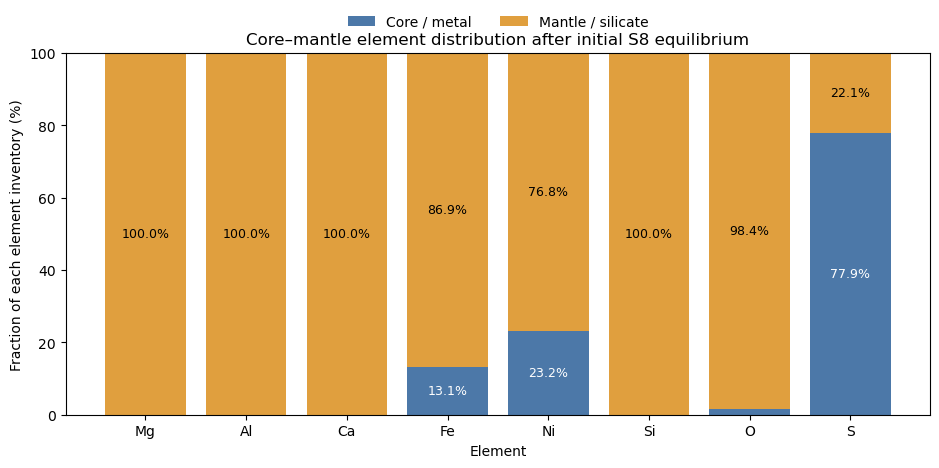

In [6]:
# Element inventories after equilibrium. Oxygen in the mantle includes
# the stoichiometric oxygen carried by every tracked silicate oxide.
element_phase_mol = pd.DataFrame({
    "core_metal": {
        "Mg": 0.0, "Al": 0.0, "Ca": 0.0,
        "Fe": result["a_"], "Ni": result["b_"],
        "Si": result["c_"], "O": result["d_"],
        "S": result["S_met_"],
    },
    "mantle_silicate": {
        "Mg": params.u, "Al": params.m, "Ca": params.n,
        "Fe": result["x_"], "Ni": result["y_"],
        "Si": result["z_"],
        "O": (result["x_"] + result["y_"] + 2.0 * result["z_"]
              + params.u + 1.5 * params.m + params.n),
        "S": result["S_sil_"],
    },
})
element_distribution_percent = element_phase_mol.div(
    element_phase_mol.sum(axis=1), axis=0
) * 100.0
display(element_distribution_percent)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
elements = element_distribution_percent.index
core_fraction = element_distribution_percent["core_metal"]
mantle_fraction = element_distribution_percent["mantle_silicate"]
bars_core = ax.bar(elements, core_fraction, color="#4C78A8",
                   label="Core / metal")
bars_mantle = ax.bar(elements, mantle_fraction, bottom=core_fraction,
                     color="#E09F3E", label="Mantle / silicate")
for x_position, core_value, mantle_value in zip(
    range(len(elements)), core_fraction, mantle_fraction
):
    if core_value >= 3.0:
        ax.text(x_position, core_value / 2.0, f"{core_value:.1f}%",
                ha="center", va="center", color="white", fontsize=9)
    if mantle_value >= 3.0:
        ax.text(x_position, core_value + mantle_value / 2.0,
                f"{mantle_value:.1f}%", ha="center", va="center",
                color="black", fontsize=9)
ax.set_ylabel("Fraction of each element inventory (%)")
ax.set_xlabel("Element")
ax.set_title("Core–mantle element distribution after initial S8 equilibrium")
ax.set_ylim(0, 100)
ax.legend(frameon=False, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, 1.14))
fig.tight_layout()
plt.show()